In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/kenya.csv")

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [2]:
# Replace -999
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64
...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16


In [3]:
# Create DATE column
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

In [4]:
# Add Month
df["Month"] = df["DATE"].dt.month


In [5]:
# Add Country column
df["Country"] = "Kenya"

In [6]:
df.duplicated().sum()

np.int64(0)

No duplicate rows found

In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


- Average temperature (T2M) is higher at 20.43°C, with daily maximums (T2M_MAX) reaching up to 34.27°C.
- Precipitation (PRECTOTCORR) shows a maximum of 51.65 mm, with a mean of 1.47 mm, indicating that most days have light rain while a few have heavy storms.
- Humidity (RH2M) ranges from 28.4% to 91.1% → this wide range suggests clear seasonal transitions between dry and humid months.
- Wind Speed (WS2M) averages 3.06 m/s, showing a breezier environment than previously recorded.

In [8]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
DATE           0
Month          0
Country        0
dtype: int64

- Dataset has negligible missing values (<1%)
- Forward fill was applied for consistency

In [9]:
(df.isna().sum() / len(df)) * 100

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
DATE           0.0
Month          0.0
Country        0.0
dtype: float64

In [10]:
from scipy import stats

z_scores = np.abs(stats.zscore(df[[
    "T2M", "T2M_MAX", "T2M_MIN", 
    "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"
]].dropna()))

outliers = (z_scores > 3).sum()
outliers

np.int64(124)

- 137 outliers detected using Z-score > 3
- Outliers retained because they may represent extreme climate events

In [11]:
df = df.ffill()

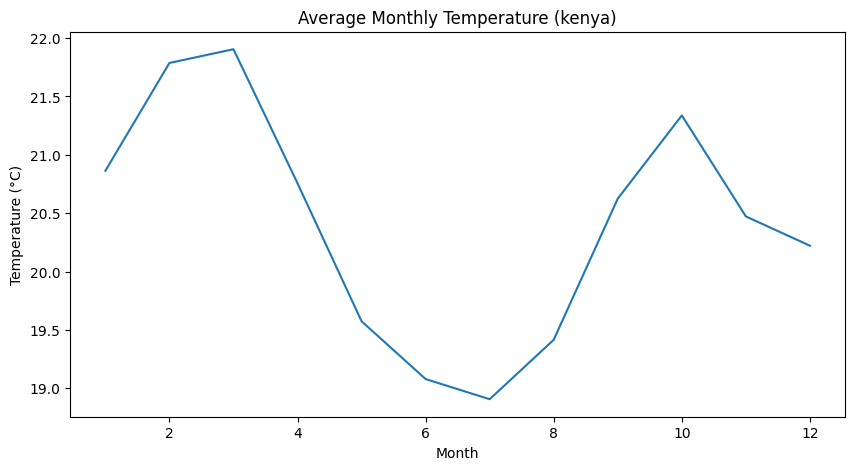

In [12]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line", figsize=(10,5))
plt.title("Average Monthly Temperature (kenya)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

- Highest temprature occur around March-April
- Lowest temprature occur around  July

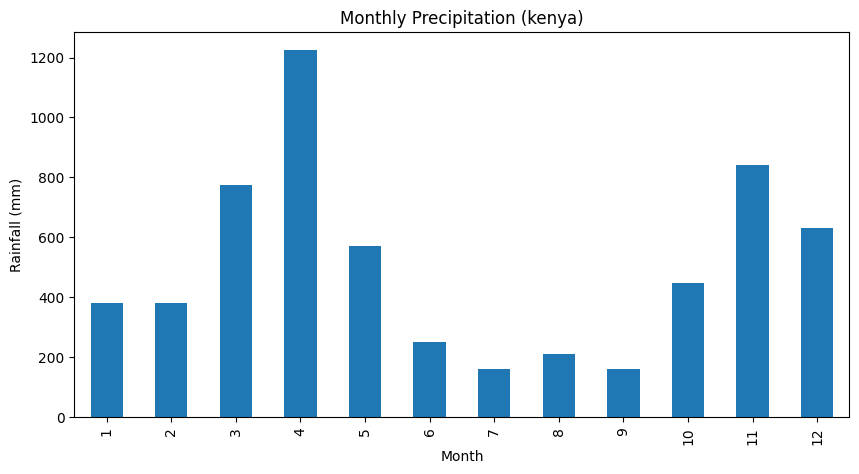

In [13]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar", figsize=(10,5))
plt.title("Monthly Precipitation (kenya)")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

- Rainfall peaks in April
- Less rainfall on July

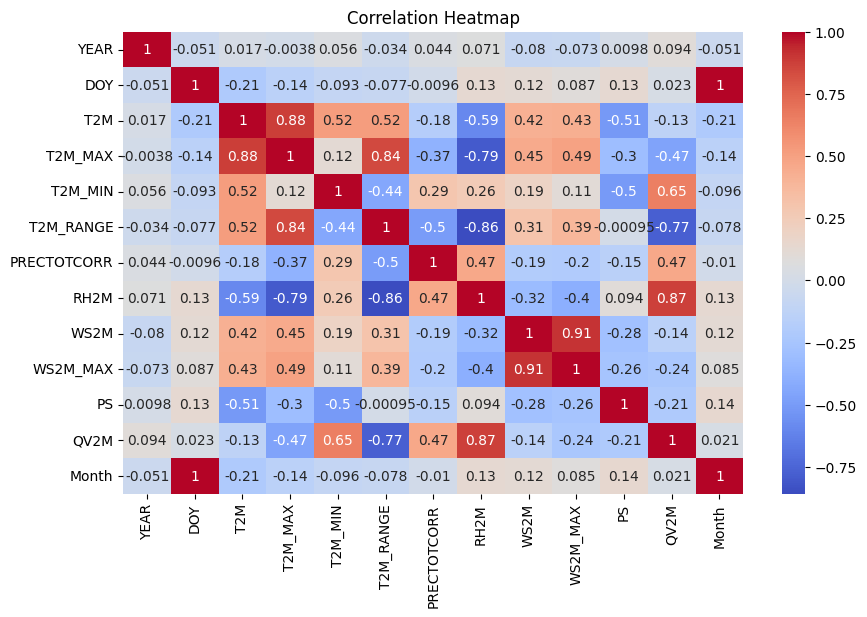

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

- T2M vs T2M_MAX: There is a strong positive correlation (0.88), meaning as average temperatures rise, daily maximums follow very closely.
- T2M vs RH2M: A moderate negative correlation (-0.59) confirms that hotter days are typically associated with lower humidity.
- WS2M vs WS2M_MAX: An extremely strong positive correlation (0.91) shows that average wind speeds and peak gusts are almost perfectly linked.
- RH2M vs T2M_RANGE: A very strong negative correlation (-0.86) suggests that days with a wide temperature swing (hot days/cool nights) are much drier.

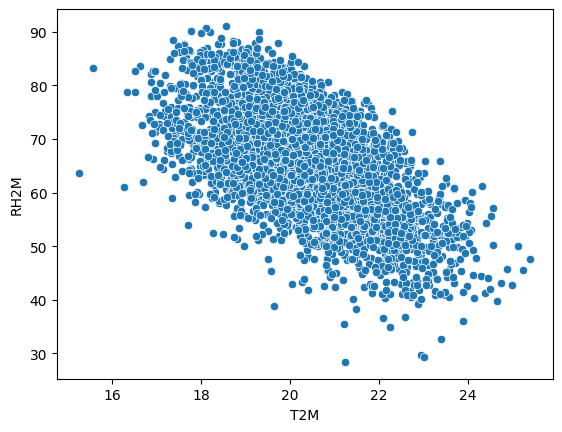

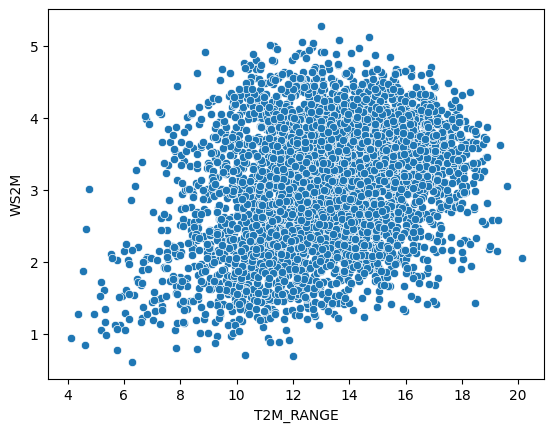

In [15]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

- T2M vs. RH2M: The data shows a downward trend, where humidity (RH2M) drops from ~90% at 16°C to below 40% as temperatures approach 24°C, confirming a clear inverse relationship.
- T2M_RANGE vs. WS2M: There is a positive correlation indicating that wind speeds are higher (reaching up to 5 m/s) on days with a larger temperature spread, typically between 10°C and 16°C.

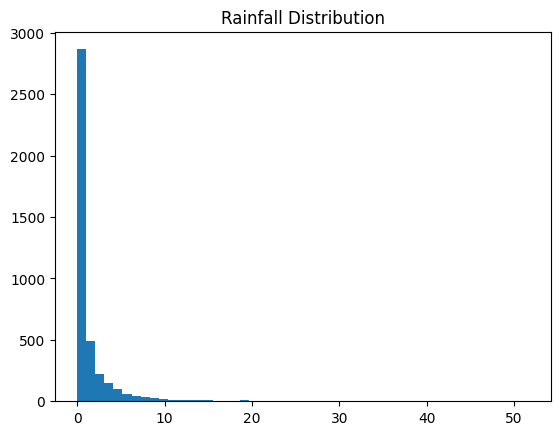

In [16]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.show()

- few high values and many low vlaues

In [17]:
df.to_csv("../data/kenya_clean.csv", index=False)